## قرايه الملف 

In [93]:
import pandas as pd

df = pd.read_csv('loan_data_set.csv')

df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Y


## معلومات عن الملف 

In [94]:
df.info()
# لو تلاحظ ان المعلومات ناقصه عندك خخيارات يا تمسحها لان بيانات كثيره ومارح تاثر او تحط متوسط القيم 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


## نقدر نطلع الوصف الاحصائي 

In [95]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## نبدا الان نعالج البيانات 

In [96]:
# لو تلاحظ في عمود Dependents فيه قيمه 3 + وهذا غلط حنا نبي 3 بس 
# هذا السطر يمنع التحذيرات ويسمح لـ replace بتحويل الأنواع مباشرة
pd.set_option('future.no_silent_downcasting', True)
df = pd.read_csv('loan_data_set.csv')
# استخدام replace
df['Dependents'] = df['Dependents'].replace({'3+': 3})
df['Loan_Status'] = df['Loan_Status'].replace({'N': 0, 'Y': 1}).astype(int)
df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].replace({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].replace({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].replace({'Yes': 1, 'No': 0})

# تحويل عمود Dependents لرقمي لتفادي خطأ حساب المتوسط
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce') 

# لاحظ اننا نرقم القيم بدون labelencoder و الهدف ننوع الطرق 

# الان نبي نستبدل القيم الفاررغه بالمتوسط 
cols_to_impute = [
    'LoanAmount',
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].mean())

# نبينحذف عمود id  لان ما نحتاجه 
df = df.drop('Loan_ID', axis=1)

## الان نحدد عمود الدخل و الخرج x and y 

In [97]:
# راح نختار كل الاعمده ما عدا الاخير راح لانخليه لل x 
x = df.drop('Loan_Status', axis = 1)

# اما yراح يكون هو العمود الاخير و الي يحدد اذا ياخذ القرض او لا 

y = df['Loan_Status']

## نفصل قيم الخرج الواي 


In [98]:
import matplotlib.pyplot as plt 
countvalue = y.value_counts()
countvalue
# هتا تطلع كم واحد يقدر ياخذ قرض 1 و واحد ما ياخذ 0

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [99]:
labels = countvalue.index.to_list()
print(labels)
# راح يطلع لك كل القيم الموجوده في العمود الاخير 

[1, 0]


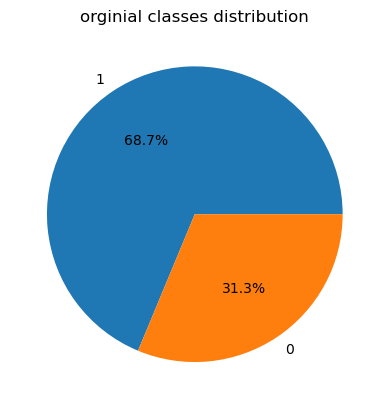

In [100]:
# الان نبي نرسم بناء على العمود الاخير 
plt.title('orginial classes distribution')
#autopct كم رقم راح تطلعه بعد الفاصله 
plt.pie(x = countvalue , labels = labels , autopct = '%1.1f%%')

plt.show()

# لو تلاحظ لازم نوازن الاصناف لان صنف 1 او نعم  هو الاكثر بكثير 
# بمعنى لازم يكونون متساويين كلهم 50

before resampleing  614
after resampleing  844


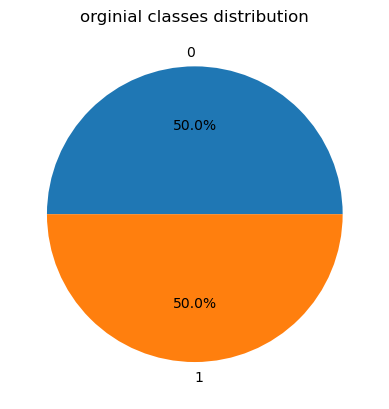

In [101]:
# لازم نضيف امثله عشان نوزن الاصناف بتساوي 
# resample التي تحدد جزء من البيانات 
from sklearn.utils import resample 

# في البدايه اطبع عدد القيم الموجوده داخل اعمده الدخل قبل resample
print('before resampleing ' , len(x) )

#راح نقول جب جميع القيم الي تحتوي على صفر في العمود الاخير 
df_0 = df[df['Loan_Status']== 0]
#راح نقول جب جميع القيم الي تحتوي على واحد في العمود الاخير 
df_1 = df[df['Loan_Status']== 1]
# راح نقول عطني عدد القيم الي 1
count_1 = df_1['Loan_Status'].count()
# الحين نقول نبي عدد الصفر لازم يكزن نفس عدد الواحد عن طريق resample 
df_0_upsampled = resample(df_0 , n_samples = count_1 , replace = True )
# الان راح اسوي اطار بيانات جديد اجمع عدد 1 و عدد 0 بعد ما زودته نفس عدد 1 
# و الجمع راح يكون عن طريق concat
df = pd.concat([df_0_upsampled , df_1])
# الان نحدد عمود الدخل و الخرج بعد ما سويت اطار البيانات الجديد 
x = df.drop('Loan_Status', axis = 1)
print('after resampleing ' , len(x) )
y = df['Loan_Status']
# الان نعيد نرسم من جديد نفس الخليه الي فوق
countvalue = y.value_counts()
labels = countvalue.index.to_list()
plt.title('orginial classes distribution')
#autopct كم رقم راح تطلعه بعد الفاصله 
plt.pie(x = countvalue , labels = labels , autopct = '%1.1f%%')

plt.show()
# والحين سوينا توازن للاصناف تم اضافه 230 الى امثله

## بعد ما جهزنا البيانات نقسم البيانات 

In [102]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , train_size = 0.8 , random_state = 0 )

## الان نبي نبني النموذج

In [103]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## الان نخليه يتنبئ 

In [104]:
y_pred = model.predict(x_test) 

## الان نقيم النموذج 

In [108]:
from sklearn import metrics 
cm = metrics.confusion_matrix(y_test, y_pred)

print(cm) 
# نحسب accuracy 
accuracy = metrics.accuracy_score(y_test, y_pred)
print("the accuracy :", accuracy)
#نحسب precision 
precision = metrics.precision_score(y_test, y_pred)
print("the precision :", precision)
#نحسب recall
recall = metrics.recall_score(y_test, y_pred)
print("the recall :", recall)
f1 = metrics.f1_score(y_test, y_pred)
print("the f1 :", f1)
# دقه تنبؤ النموذج 84 

[[74  7]
 [20 68]]
the accuracy : 0.8402366863905325
the precision : 0.9066666666666666
the recall : 0.7727272727272727
the f1 : 0.8343558282208589


<Axes: >

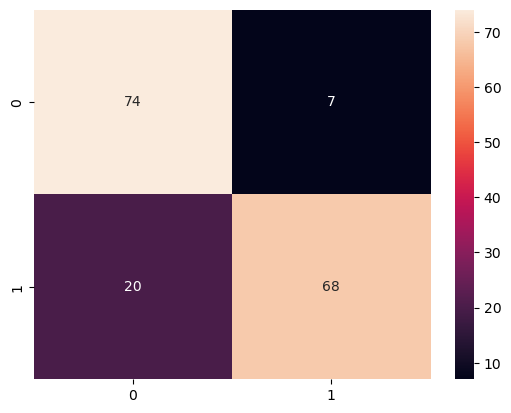

In [110]:
# نمثل مرئيا مصفوفه الارتباك 
import seaborn as sns 
sns.heatmap(cm , annot = True)